In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
transform=transforms.Compose([
    transforms.Resize((128,128)),     #將圖片大小縮放至(128*128)
    transforms.ToTensor()
])

In [3]:
DATA_DIR = r'C:\Users\MJ\Desktop\fish\Fish_Dataset\Fish_Dataset'
model_algo="alexnet"


In [4]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,transform,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root, transform=transform)
        self.classes = self.images.class_to_idx.items()
        self.flag= [False] * len(self.images)
        self.decision_mode=decision_mode
        
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        
        if(self.decision_mode==False):
            image, label=self.images[idx]
            
            return image, label,idx
        else:
            image, _=self.images[idx]

            label=int(self.flag[idx])
            return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = True
    

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.2 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [6]:
# create data loaders
batch_size = 64 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
test_dl = DataLoader(testset, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
#建立模型框架
def model_create(model_algo):
    model = getattr(models,model_algo)(weights=True)
    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, len(trainset.dataset.classes))
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,len(trainset.dataset.classes))
    
    return model

In [8]:
#訓練模型
def trainer(epochs,model,criterion,optim,data_dl):
        for epoch in range(epochs):
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in data_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上

                        out = model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)  

                        loss = criterion(out, target)
                        loss.backward()
                        
                        optim.step()
                print(f'Epoch{epoch}:{loss.item()}')
                
        return model
                

In [9]:
#將模型建立框架後並訓練
def model_train(model_algo,data_dl,data_name,epochs):
    model=model_create(model_algo)
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=1e-4)
    if(data_name=="decision"):
        trainset.dataset.decision_mode=True
        model=trainer(epochs,model,criterion,optim,data_dl)
        trainset.dataset.decision_mode=False
    else:
        model=trainer(epochs,model,criterion,optim,data_dl)
    torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

In [10]:
# model_0=model_train(model_algo,train_dl,"0",10)
model_0 = torch.load(f'model_{model_algo}_0.pth')

In [11]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        loss = criterion(out, target)
                        
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        
        return total_loss,accu,flat_true,flat_pred

In [12]:
idx2class = {v: k for k, v in trainset.dataset.classes}
train_loss,train_accu,flat_true,flat_pred=evaluate_model(model_0,train_dl,train_size)
confusion_matrix_train = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
train_loss,train_accu

(0.26224510011297686, 0.935)

In [13]:
valid_loss,valid_accu,flat_true,flat_pred=evaluate_model(model_0,valid_dl,valid_size)
confusion_matrix_valid = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
valid_loss,valid_accu

(0.22166548271973927, 0.9433333333333334)

In [15]:
test_loss,test_accu,flat_true,flat_pred=evaluate_model(model_0,test_dl,test_size)

In [16]:
test_loss,test_accu

(0.2705552965071466, 0.9338888888888889)

In [17]:
#將資料切分成true and false
def split_data(model_algo):
    model_0.eval()
  
    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in train_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for idx,result in zip(idx,torch.eq(target,y_pred_tag)):

                if(result.cpu().numpy()):
                    indexT.append(idx.cpu().numpy().item())
                    trainset.dataset.update_flag(idx)
                else:
                    indexF.append(idx.cpu().numpy().item())
            
        torch.cuda.empty_cache() 
    return indexF,indexT

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_algo)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=32)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=32)

decision_dl = DataLoader(trainset, batch_size=batch_size)


In [19]:
len(indexF),len(indexT)

(702, 10098)

In [20]:
#訓練模型T、F、decision
# model_T=model_train(model_algo,Tdl,"T",10)
model_T=torch.load(f'model_{model_algo}_T.pth')

In [21]:
# model_F=model_train(model_algo,Fdl,"F",20)
model_F=torch.load(f'model_{model_algo}_F.pth')

In [22]:
# model_decision=model_train(model_algo,decision_dl,"decision",20)
model_decision = torch.load(f'model_{model_algo}_decision.pth')

In [23]:
torch.cuda.empty_cache()

In [24]:
T_loss,T_accu,flat_true,flat_pred=evaluate_model(model_T,Tdl,len(Tdataset))
confusion_matrix_T_train = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
T_loss,T_accu

(0.06778904448351333, 0.9799960388195682)

In [25]:
F_loss,F_accu,flat_true,flat_pred=evaluate_model(model_F,Fdl,len(Fdataset))
confusion_matrix_F_train = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
F_loss,F_accu

(0.38201117978306576, 0.9031339031339032)

In [26]:
trainset.dataset.decision_mode=True
decision_loss,decision_accu,flat_true,flat_pred=evaluate_model(model_decision,decision_dl,train_size)
confusion_matrix_decision_train= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
trainset.dataset.decision_mode=False

In [27]:
decision_loss,decision_accu

(0.31303149520156526, 0.9719444444444445)

In [29]:
torch.cuda.empty_cache()
correct=0
flat_true=[]
flat_pred=[]
decision_valid_accu=0
with torch.no_grad():
        model_0.eval()   
        for data, target,idx in valid_dl:

                data,target=data.to(device),target.to(device)
                out_growth= model_0(data)   #原始model
                _, y_pred_tag = torch.max(out_growth, dim = 1)

                out_predict= model_decision(data)  #預測要用哪個model
                _, predict = torch.max(out_predict, dim = 1)
       
                for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                        if(result==pred):
                                correct+=1
                        flat_true.append(result.cpu().numpy())
                        flat_pred.append(pred.cpu().numpy())

decision_valid_accu=correct/valid_size

print("decision_valid accu=",decision_valid_accu) 
confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})

decision_valid accu= 0.9769444444444444


In [30]:
    
def evaluate_model_TF(TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    model_to_evaluate = model_T if TorF == "T" else model_F
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model_to_evaluate(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    return valid_loss,valid_accu,flat_true,flat_pred

In [31]:
T_valid_loss,T_valid_accu,flat_true,flat_pred=evaluate_model_TF("T")
confusion_matrix_T_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)

F_valid_loss,F_valid_accu,flat_true,flat_pred=evaluate_model_TF("F")
confusion_matrix_F_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)


Model_T valid loss=0.054558875788702055, accu=0.9840989399293286,sample_number=3396
Model_F valid loss=0.3821439066855943, accu=0.9019607843137255,sample_number=204


In [32]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]


    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)
            
        
            for pred,d,t in zip(y_pred_tag,data,target):
                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    

                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    
           
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    return total_loss,accu,flat_true,flat_pred
        

In [33]:
total_train_loss,total_train_accu,flat_true,flat_pred=total_model_evaluate(train_dl,train_size)
confusion_matrix_total_train = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
total_train_loss,total_train_accu

(0.10948417313534904, 0.9706481481481481)

In [34]:
total_valid_loss,total_valid_accu,flat_true,flat_pred=total_model_evaluate(valid_dl,valid_size)
confusion_matrix_total_valid = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
total_valid_loss,total_valid_accu

(0.08334658625639148, 0.9766666666666667)

In [14]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))

    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [35]:
model_algos=['Model_0',"Model_decision","Model_T","Model_F","Total_Model"]

In [36]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,"NA",T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [37]:
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}

In [38]:
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.262245,0.935000,0.221665,0.943333
1,Model_decision,0.313031,0.971944,NA,0.976944
2,Model_T,0.067789,0.979996,0.054559,0.984099
3,Model_F,0.382011,0.903134,0.382144,0.901961
4,Total_Model,0.109484,0.970648,0.083347,0.976667


In [ ]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision")

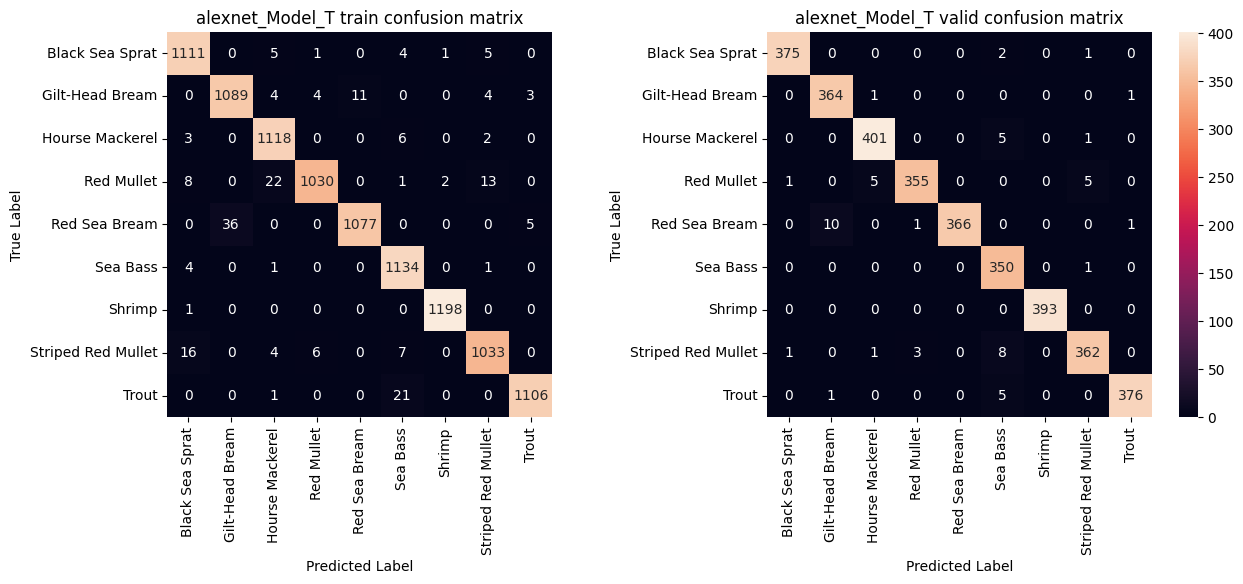

In [39]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

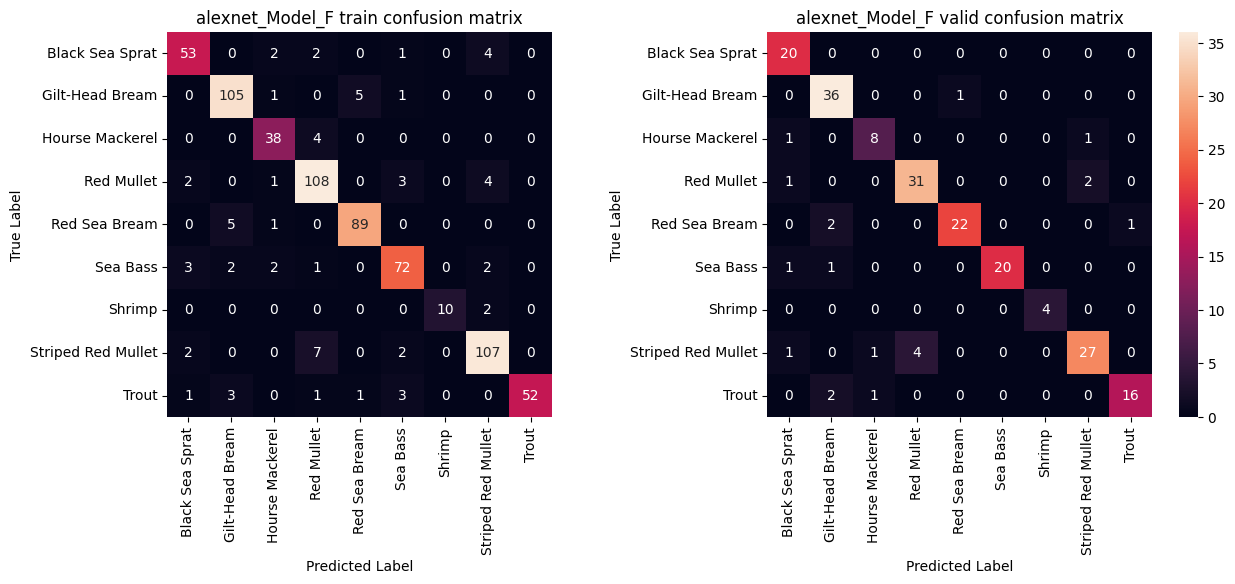

In [40]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

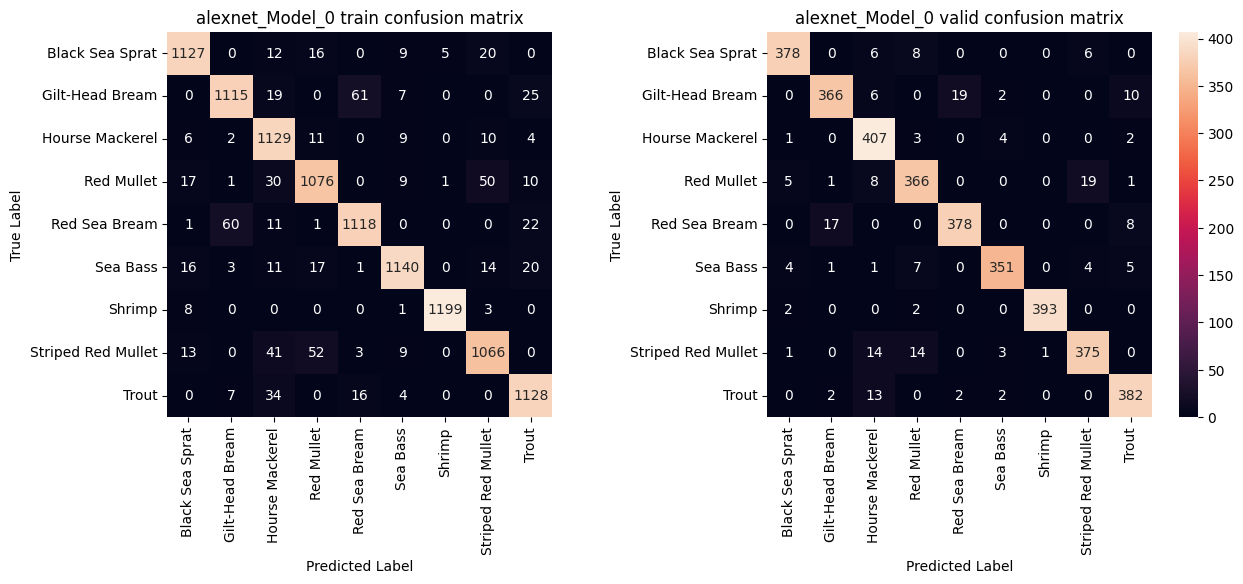

In [41]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

In [ ]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")